# H2D2 (H-alpha / D-alpha) spectroscopy pipeline

Thin driver around `pipeline.py`. Validate on **one spectrum** first, then run all files and pool them.

Stages: load -> helium offset calibration -> crop to the doublet -> fit two peaks + linear background -> read off line centers.

**Line shape** (`CONFIG["lineshape"]`): a **Voigt** profile per line — a Gaussian (Doppler + instrument) convolved with a Lorentzian (lifetime + pressure), with $\sigma$ and $\gamma$ shared across the H/D doublet:
$$I(\lambda)=B+m\lambda+A_H\,V(\lambda-\lambda_H;\sigma,\gamma)+A_D\,V(\lambda-\lambda_D;\sigma,\gamma)$$
(Set `CONFIG["lineshape"]="gaussian"` for the simpler two-Gaussian model.)

From the fit we extract $\lambda_H$, $\lambda_D$, and the separation $\Delta\lambda=\lambda_H-\lambda_D$. The single-pixel maximum is a poor line center at this resolution, so we fit; and a constant calibration offset cancels in $\Delta\lambda$, so the **separation** is the robust quantity to report (per the handout).

In [1]:
import importlib
import numpy as np
import pipeline
importlib.reload(pipeline)  # re-run this cell after editing pipeline.py
from pipeline import (CONFIG, run_pipeline, load_spectrum, crop, fit_spectrum,
                      plot_spectrum, plot_fit, plot_combined, combine_runs,
                      list_runs, two_gaussian, two_voigt, one_voigt,
                      compute_helium_offset, plot_helium, write_report,
                      physical_widths)

# Show inline in the notebook in addition to saving PNGs
%matplotlib inline
CONFIG["show"] = True

## Config toggles
Adjust here, then re-run the cells below.

In [2]:
# ===================== DATASET =====================
CONFIG["data_root"] = "H2D2 Data"      # folder of HR4C2500 spectra (Trial 1..7)
CONFIG["save_dir"]  = "H2D2 Processed Outputs"

# --- fit window (nm): tight enough to exclude stray lines, wide enough for bg
CONFIG["fit_window"] = (654.5, 656.4)

# ===================== LINE SHAPE =====================
# "voigt"  -> Gaussian (Doppler+instrument) (x) Lorentzian (lifetime+pressure),
#             shared sigma & gamma across the H/D doublet (physically motivated).
# "gaussian" -> the simpler two-Gaussian model.
# The helium calibration line uses the SAME shape for consistency.
CONFIG["lineshape"] = "voigt"
CONFIG["fit"].update(sigma_guess=0.03, sigma_min=0.005, sigma_max=0.30,
                     gamma_guess=0.01, gamma_max=0.30)

# ===================== UNCERTAINTY =====================
# Readout / quantization: +/- 1/2 of the last recorded decimal place.
CONFIG["readout"].update(wavelength_nm=5e-6,   # wavelengths printed to 1e-5 nm
                         intensity=5e-3)       # intensities printed to 1e-2 counts

# OceanView pixel->wavelength calibration of the HR4000 (drives the wavelength
# CALIBRATION (scale) uncertainty; the files already store wavelength=poly(pixel)).
CONFIG["calibration"]["poly"].update(c0=629.6664627, c1=0.018337985,
                                     c2=-1.22763e-06, c3=0.0,
                                     r_squared=0.99999993, n_pixels=3648)

# ===================== HELIUM OFFSET =====================
# Measure the absolute wavelength shift from the He I calibration trials and add
# it to every spectrum, so the H2D2 centers become MEASURED wavelengths.
CONFIG["helium_cal"].update(enabled=True, data_root="Helium Calibration Data",
                            nist_line=667.81517, nist_line_err=1e-4,
                            fit_window=(667.00, 667.55), sigma_guess=0.02)

# --- literature reference (annotation only)
CONFIG["lambda_H_lit"], CONFIG["lambda_D_lit"], CONFIG["dlambda_lit"] = 656.279, 656.100, 0.179

print("line shape:", CONFIG["lineshape"], "| H2D2 runs found:")
for r in list_runs():
    print(" ", r)

line shape: voigt | H2D2 runs found:
  H2D2 Data\Trial 1.txt
  H2D2 Data\Trial 2.txt
  H2D2 Data\Trial 3.txt
  H2D2 Data\Trial 4.txt
  H2D2 Data\Trial 5.txt
  H2D2 Data\Trial 6.txt
  H2D2 Data\Trial 7.txt


## 0. Helium wavelength-offset calibration
Fit the known He I line (NIST 667.81517 nm) in each helium trial, average the measured shift, and **add** it to every spectrum so the H2D2 line centers become *measured* absolute wavelengths. A constant offset cancels in $\Delta\lambda$, so this only fixes the absolute scale (and contributes its uncertainty to the absolute centers) — exactly what's needed for particle-mass calculations.

Helium wavelength-offset calibration  [voigt]
  NIST He I line   : 667.81517 nm
  trials           : 3
    HR4C25001_14-21-45-263       center 667.2758 +/- 0.0012 nm  (chi2/dof 8.1)  offset +0.5393 nm
    HR4C25001_14-22-03-715       center 667.2759 +/- 0.0012 nm  (chi2/dof 7.9)  offset +0.5393 nm
    HR4C25001_14-22-18-299       center 667.2759 +/- 0.0012 nm  (chi2/dof 8.0)  offset +0.5393 nm
  combined center  : 667.2759 +/- 0.0007 nm
  trial scatter    : 0.0000 nm
  OFFSET (added)   : +0.5393 +/- 0.0007 nm


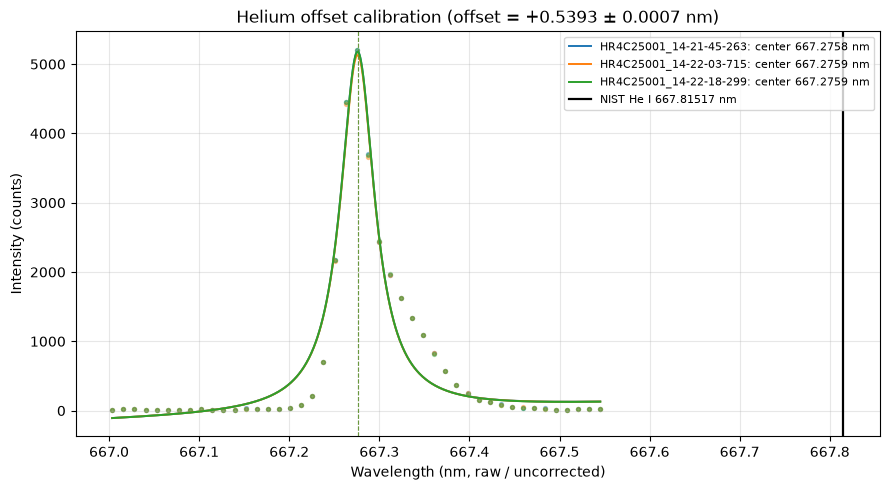

In [3]:
# Fit the He I line in each helium trial, average the measured shift, and APPLY
# it (added to every subsequent load). Run this BEFORE the H2D2 fits below.
offset = compute_helium_offset(CONFIG, apply=True)
print(offset.summary())
_ = plot_helium(offset)

## 1-4. Single spectrum: load, crop, fit
Validate the window and fit on one file before running them all.

loaded 3648 points, 630.2-680.8 nm


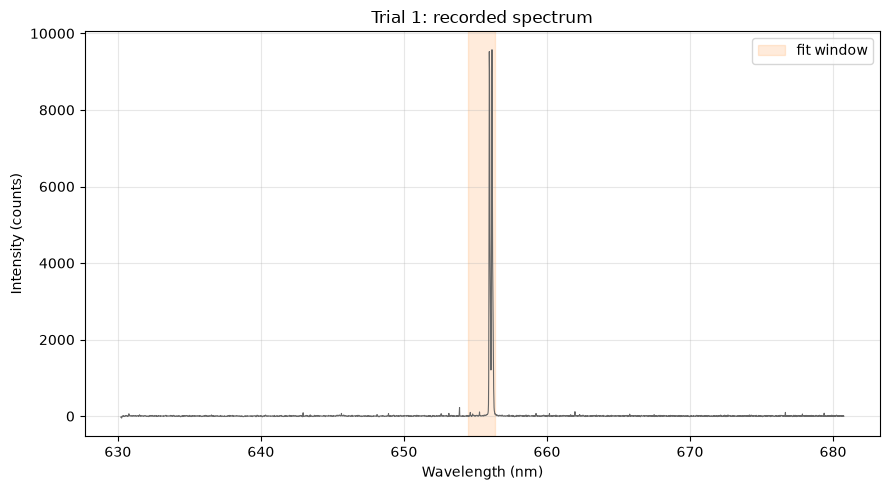

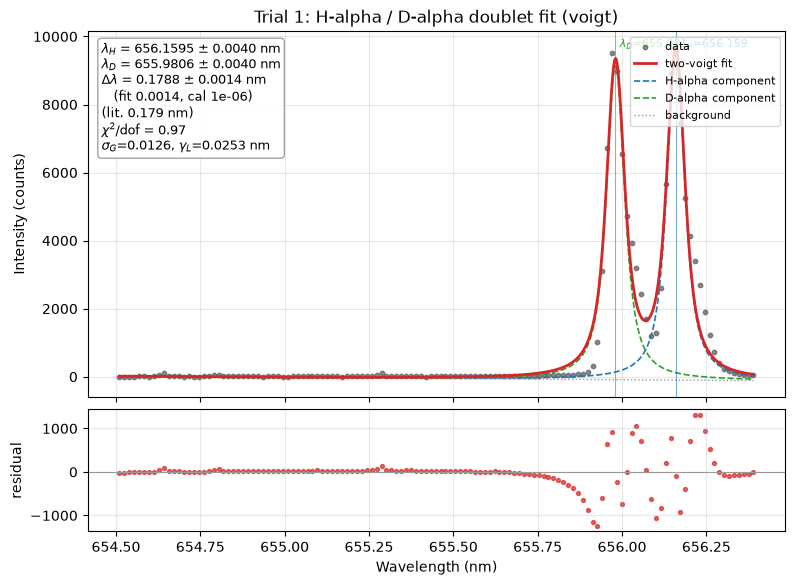

Run: Trial 1  [voigt]
  fit window       : 654.510 - 656.389 nm (130 pts)
  converged        : True   chi2/dof = 0.97
  lambda_H (H-alpha): 656.1595 +/- 0.0040 nm (fit 0.0010, cal 0.0039)
  lambda_D (D-alpha): 655.9806 +/- 0.0040 nm (fit 0.0010, cal 0.0039)
  Delta lambda      : 0.1788 +/- 0.0014 nm (fit 0.0014, cal 1.1e-06)
  widths (shared)  : Gaussian sigma 0.0126 nm (FWHM 0.0298), Lorentzian gamma 0.0253 nm (FWHM_V 0.0650)


In [4]:
RUN = list_runs()[0]          # or paste a specific filename / path
df = load_spectrum(RUN)
print(f"loaded {len(df)} points, {df['wavelength'].min():.1f}-{df['wavelength'].max():.1f} nm")

_ = plot_spectrum(df, RUN)    # full spectrum, fit window shaded
res = fit_spectrum(df, RUN)   # crop + two-Gaussian fit
_ = plot_fit(res)             # data + fit + components + residuals
print(res.summary())

## All runs
Run the full pipeline on every spectrum (writes `H2D2 Processed Outputs/<trial>/1_spectrum.png`, `2_fit.png`). Inline display is suppressed here to avoid flooding the notebook with figures — re-open the PNGs from the folders.

In [5]:
_show = CONFIG["show"]; CONFIG["show"] = False
results = {}
for r in list_runs():
    res = run_pipeline(r, plots=True)
    results[res.run] = res
CONFIG["show"] = _show

# per-trial: total +/- on Delta lambda, split into fit (statistical) vs cal
print(f"{'run':10s} {'lambda_H':>10s} {'lambda_D':>10s} "
      f"{'Delta lambda (nm)':>22s} {'fit':>7s} {'cal':>8s} {'chi2/dof':>9s}")
for name, r in results.items():
    print(f"{name:10s} {r.lambda_H:10.4f} {r.lambda_D:10.4f}   "
          f"{r.dlambda:.4f} +/- {r.dlambda_err:.4f}   {r.dlambda_err_fit:.4f} "
          f"{r.dlambda_err_cal:.1e}   {r.chi2_dof:8.1f}")

run          lambda_H   lambda_D      Delta lambda (nm)     fit      cal  chi2/dof
Trial 1      656.1595   655.9806   0.1788 +/- 0.0014   0.0014 1.1e-06        1.0
Trial 2      656.1597   655.9811   0.1786 +/- 0.0014   0.0014 1.1e-06        1.0
Trial 3      656.1595   655.9810   0.1784 +/- 0.0014   0.0014 1.1e-06        1.0
Trial 4      656.1593   655.9807   0.1786 +/- 0.0014   0.0014 1.1e-06        1.0
Trial 5      656.1591   655.9805   0.1786 +/- 0.0014   0.0014 1.1e-06        1.0
Trial 6      656.1594   655.9809   0.1785 +/- 0.0014   0.0014 1.1e-06        1.0
Trial 7      656.1596   655.9810   0.1786 +/- 0.0014   0.0014 1.1e-06        0.9


## Combined result + uncertainty budget
Each quantity is reported with its error split into three terms, combined in quadrature:

- **stat** — the per-trial fit error (independent between trials), pooled by inverse-variance weighting with Birge inflation; this term shrinks $\sim 1/\sqrt{N}$.
- **cal** — the OceanView wavelength-calibration accuracy, taken as a fractional (scale) error $\mathrm{rel} = \sqrt{1-R^2}\,\sigma_\lambda/\bar\lambda$ from the given coefficients ($R^2=0.99999993$). It is **common-mode** (same spectrometer every trial) so it does *not* average down, and it **nearly cancels in $\Delta\lambda$** (a common additive offset cancels in $\lambda_H-\lambda_D$; only the scale survives).
- **read** — the $\pm\tfrac12$-last-decimal readout floor (wavelength $5\times10^{-6}$ nm, intensity $5\times10^{-3}$ counts).

The upshot: the **absolute** centers $\lambda_H,\lambda_D$ are calibration-limited (~0.004 nm), while the **separation** $\Delta\lambda$ is statistics-limited and calibration-immune — exactly why the handout has us report $\Delta\lambda$.

Combined over 7 trials   (rel. cal 5.89e-06, He offset err 0.0007 nm)

  lambda_H     = 656.1594 +/- 0.0039 nm
                   stat 0.0004  |  cal 3.9e-03  |  read 5.0e-06 nm
  lambda_D     = 655.9808 +/- 0.0039 nm
                   stat 0.0004  |  cal 3.9e-03  |  read 5.0e-06 nm
  Delta lambda = 0.1786 +/- 0.0005 nm
                   stat 0.0005  |  cal 1.1e-06  |  read 7.1e-06 nm

  plain mean Delta lambda = 0.1786 +/- 0.0000 nm (SEM)
  run-to-run scatter      = 0.0001 nm
  literature Delta lambda = 0.179 nm

  Voigt widths: Gaussian sigma 0.0130 nm (FWHM 0.0306), Lorentzian gamma 0.0253 nm
  instrumental sigma (He) 0.0010 nm -> Doppler sigma 0.0129 nm -> T ~ 4243 K


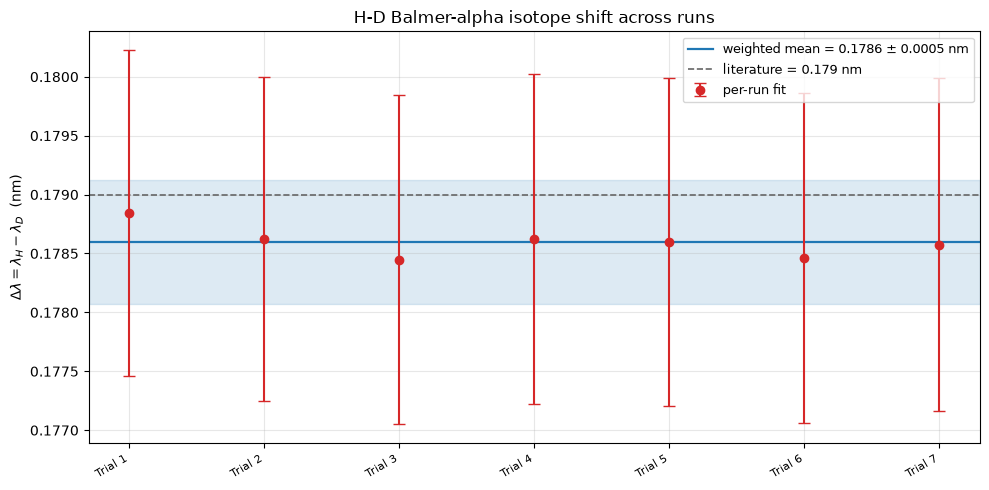


Text summary written to: H2D2 Processed Outputs\H2D2_summary.txt


In [6]:
comb = combine_runs(results)
print(f"Combined over {comb['n_runs']} trials   (rel. cal {comb['rel_cal']:.2e}, "
      f"He offset err {comb['offset_err']:.4f} nm)\n")
for k, lab in (("lambda_H", "lambda_H"), ("lambda_D", "lambda_D"), ("dlambda", "Delta lambda")):
    print(f"  {lab:12s} = {comb[k]:.4f} +/- {comb[k+'_err']:.4f} nm")
    print(f"  {'':12s}     stat {comb[k+'_stat']:.4f}  |  cal {comb[k+'_cal']:.1e}  |  read {comb[k+'_read']:.1e} nm")
print(f"\n  plain mean Delta lambda = {comb['dlambda_mean']:.4f} +/- {comb['dlambda_sem']:.4f} nm (SEM)")
print(f"  run-to-run scatter      = {comb['dlambda_std']:.4f} nm")
print(f"  literature Delta lambda = {CONFIG['dlambda_lit']:.3f} nm")

# Voigt width decomposition: Gaussian (Doppler+instrument) vs Lorentzian, and the
# implied gas temperature (using the He line as the instrumental-width proxy).
if CONFIG["lineshape"] == "voigt":
    pw = physical_widths(results, offset)
    print(f"\n  Voigt widths: Gaussian sigma {pw['sigma_gauss']:.4f} nm "
          f"(FWHM {pw['fwhm_gauss']:.4f}), Lorentzian gamma {pw['gamma_lor']:.4f} nm")
    if np.isfinite(pw.get("T_doppler", np.nan)):
        print(f"  instrumental sigma (He) {pw['sigma_inst']:.4f} nm -> "
              f"Doppler sigma {pw['sigma_doppler']:.4f} nm -> T ~ {pw['T_doppler']:.0f} K")
    else:
        print("  (instrument width >= observed Gaussian width; Doppler T not resolvable)")

_ = plot_combined(results)    # Delta lambda per trial + weighted-mean band

# write the full text summary (offset calibration + per-trial fits + combined)
report_path = write_report(results, CONFIG, offset)
print(f"\nText summary written to: {report_path}")